# RQ1: Functional vs Geometric Graph Evidence

## Research Question
Do functional graphs (DE/DC) outperform geometric SD for station-level 1-hour forecasting?

## Hypothesis
H1: At least one functional configuration (DE, DC, or DE+DC) yields lower test WMAPE than SD.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import (
    HEADLINE_CONTRAST_BY_RQ,
    PRIMARY_COHORT_BY_RQ,
    canon_graph_set,
    cohort_station_indices,
    load_rq_inference_geo,
    optional_csv,
    paired_station_wmape_diff,
    relative_change,
    require_csv,
)

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

## Statistical inference (Methods)

- **H₀ / tests**: Contrasts on **mean paired per-station test WMAPE** are reported in `rq_runner/rq_hypothesis_tests.csv` (Holm-adjusted *p* within each RQ×cohort family; default α = 0.05; two-sided paired sign randomization, same helper as `train_eval`).
- **Scope**: conclusions are for this **fixed train/validation/test protocol** and test window, not automatic temporal generalization.
- **Dependence**: stations are spatially correlated; bootstrap CIs on station resamples are **approximate**. Do not relabel `train_eval_3h/station_robustness_statistics.csv` p-values as direct tests of graph-set contrasts—that file is model-vs-reference.
- **Further reading**: [docs/statistical_inference_rq.md](../docs/statistical_inference_rq.md).


In [ ]:
from IPython.display import Markdown, display

_hypothesis_path = ARTIFACT_ROOT / 'rq_runner' / 'rq_hypothesis_tests.csv'
if not _hypothesis_path.is_file():
    raise FileNotFoundError(
        f'Missing {_hypothesis_path}. After running experiment_runners, run: '
        'python -m scripts.experiments.rq_hypothesis_tests --output-dir data/artifacts/experiments/rq_runner'
    )
_rqh = pd.read_csv(_hypothesis_path)
_RQ = 'RQ1'
_rq1h = _rqh[_rqh['rq'] == _RQ].sort_values(['cohort', 'contrast']).copy()
_pc = PRIMARY_COHORT_BY_RQ[_RQ]
_rq1h['is_primary_cohort'] = _rq1h['cohort'] == _pc
display(
    Markdown(
        f'### {_RQ} hypothesis tests\n'
        f'**Primary cohort (pre-specified)**: `{_pc}` — `is_primary_cohort` marks those rows. '
        '**train_eval** robustness CSV is model-vs-reference on one graph set; **rq_hypothesis_tests** are cross-configuration contrasts (see docs).'
    )
)
_cols = [
    'cohort',
    'contrast',
    'mean_delta',
    'ci_lower',
    'ci_upper',
    'p_value',
    'p_holm',
    'reject_H0',
    'n_stations_used',
    'is_primary_cohort',
]
if 'H0' in _rq1h.columns:
    _cols = [
        'cohort',
        'contrast',
        'H0',
        'mean_delta',
        'ci_lower',
        'ci_upper',
        'p_value',
        'p_holm',
        'reject_H0',
        'n_stations_used',
        'is_primary_cohort',
    ]
display(_rq1h[_cols])

_df = _rq1h[np.isfinite(_rq1h['mean_delta'])].copy()
if not _df.empty:
    _df['label'] = _df['cohort'].astype(str) + ' / ' + _df['contrast'].astype(str)
    _df = _df.sort_values('mean_delta').reset_index(drop=True)
    y = np.arange(len(_df))
    plt.figure(figsize=(10, max(4.0, 0.35 * len(_df) + 1.0)))
    for i, row in _df.iterrows():
        color = 'darkorange' if row['is_primary_cohort'] else 'steelblue'
        elw = 2.2 if row['is_primary_cohort'] else 1.1
        lo = row['mean_delta'] - row['ci_lower']
        hi = row['ci_upper'] - row['mean_delta']
        plt.errorbar(
            [row['mean_delta']],
            [i],
            xerr=[[lo], [hi]],
            fmt='o',
            capsize=4,
            color=color,
            ecolor=color,
            elinewidth=elw,
        )
    plt.axvline(0, color='black', linewidth=0.9)
    plt.yticks(y, _df['label'])
    plt.xlabel('Mean paired Δ test WMAPE (bootstrap CI)')
    plt.title(f'{_RQ} contrasts (orange = primary cohort)')
    plt.tight_layout()
    plt.show()

_head = HEADLINE_CONTRAST_BY_RQ[_RQ]
_row = _rq1h[(_rq1h['cohort'] == _pc) & (_rq1h['contrast'] == _head)]
_exp = {'experiment_a', 'experiment_b'}
if len(_row) == 1 and _exp <= set(_row.columns):
    try:
        geo = load_rq_inference_geo(ARTIFACT_ROOT)
        idx = cohort_station_indices(
            _pc,
            train_csv=geo['train_csv'],
            graph_dir=geo['graph_dir'],
            stations_dir=geo['stations_dir'],
            sparse_quantile=geo['sparse_quantile'],
        )
        diff = paired_station_wmape_diff(
            geo['scores_dir'],
            str(_row['experiment_a'].iloc[0]),
            str(_row['experiment_b'].iloc[0]),
            idx,
        )
        if diff.size:
            plt.figure(figsize=(8, 4))
            nb = min(45, max(12, int(np.sqrt(diff.size)) * 3))
            plt.hist(diff, bins=nb, color='steelblue', edgecolor='white', alpha=0.9)
            plt.axvline(0, color='black', linewidth=1)
            plt.title(f'{_RQ} headline `{_head}` (primary `{_pc}`): paired station Δ WMAPE')
            plt.xlabel('Δ WMAPE (aligned with table mean_delta)')
            plt.tight_layout()
            plt.show()
    except Exception as exc:
        print('Skipping headline distribution plot:', exc)


In [2]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq1_rows = rq_results.filter((pl.col('rq') == 'RQ1') & (pl.col('aggregation') == 'station') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq1_rows['graph_set'] = rq1_rows['graph_set'].apply(canon_graph_set)

rq_meta_path = ARTIFACT_ROOT / 'rq_runner' / 'metadata.json'
train_eval_meta_path = ARTIFACT_ROOT / 'train_eval_3h' / 'metadata.json'

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'rq_runner/metadata.json', 'exists': rq_meta_path.exists()},
    {'artifact': 'train_eval_3h/station_robustness_statistics.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'station_robustness_statistics.csv').exists()},
    {'artifact': 'train_eval_3h/metadata.json', 'exists': train_eval_meta_path.exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ1 rows available', 'value': int(len(rq1_rows))},
    {'criterion': 'Unique graph sets', 'value': int(rq1_rows['graph_set'].nunique())},
    {'criterion': 'Any missing test_wmape', 'value': bool(rq1_rows['test_wmape'].isna().any())},
])

provenance, inclusion

(                                          artifact  exists
 0                            rq_runner/results.csv    True
 1                          rq_runner/metadata.json    True
 2  train_eval_3h/station_robustness_statistics.csv    True
 3                      train_eval_3h/metadata.json    True,
                 criterion  value
 0      RQ1 rows available      4
 1       Unique graph sets      4
 2  Any missing test_wmape  False)

In [3]:
rq1_summary = rq1_rows.groupby('graph_set', as_index=False)['test_wmape'].mean().sort_values('test_wmape')
baseline = dict(zip(rq1_summary['graph_set'], rq1_summary['test_wmape']))
sd = baseline.get('SD')

effect_rows = []
for candidate in ('DE', 'DC', 'DE+DC'):
    value = baseline.get(candidate)
    if value is None or sd is None:
        continue
    effect_rows.append({
        'comparison': f'{candidate} vs SD',
        'candidate_test_wmape': value,
        'sd_test_wmape': sd,
        'absolute_delta': value - sd,
        'relative_delta': relative_change(value, sd),
    })

rq1_effects = pd.DataFrame(effect_rows).sort_values('absolute_delta')
rq1_summary, rq1_effects

(  graph_set   test_wmape
 0        DC     0.674160
 3        SD     0.697026
 2     DE+DC     2.777475
 1        DE  1915.105228,
     comparison  candidate_test_wmape  sd_test_wmape  absolute_delta  \
 1     DC vs SD              0.674160       0.697026       -0.022866   
 2  DE+DC vs SD              2.777475       0.697026        2.080449   
 0     DE vs SD           1915.105228       0.697026     1914.408202   
 
    relative_delta  
 1       -0.032806  
 2        2.984750  
 0     2746.536588  )

In [4]:
robustness = optional_csv('train_eval_3h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'reference_model', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue'))

if robustness is None:
    print('Uncertainty artifact unavailable: train_eval_3h/station_robustness_statistics.csv')
    rq1_uncertainty = pd.DataFrame()
else:
    rq1_uncertainty = robustness.filter((pl.col('model') == 'graph_propagation')).select([
        'cohort',
        'test_station_wmape_mean',
        'test_station_wmape_ci_lower',
        'test_station_wmape_ci_upper',
        'paired_sign_permutation_pvalue',
    ]).sort('cohort').to_pandas()

rq1_uncertainty

,cohort,test_station_wmape_mean,test_station_wmape_ci_lower,test_station_wmape_ci_upper,paired_sign_permutation_pvalue
0,all,0.898479,0.868087,0.931388,1.0
1,dense,0.830226,0.798363,0.870431,1.0
2,espoo,1.014873,0.976675,1.054597,1.0
3,helsinki,0.863527,0.829668,0.905715,1.0
4,sparse,1.102018,1.052147,1.152945,1.0
5,sparse_espoo,1.267271,1.177592,1.331597,1.0
6,sparse_helsinki,1.092664,1.043416,1.146301,1.0


In [5]:
sensitivity = optional_csv('train_eval_3h/sensitivity_summary.csv', required_columns=('sensitivity_axis', 'scope', 'aggregation', 'model', 'setting', 'metric', 'delta_vs_reference'))

if sensitivity is None:
    print('Sensitivity artifact unavailable: train_eval_3h/sensitivity_summary.csv')
    rq1_sensitivity = pd.DataFrame()
else:
    rq1_sensitivity = sensitivity.filter((pl.col('model') == 'graph_propagation') & (pl.col('sensitivity_axis').is_in(['hyperparameter', 'resolution']))).sort(['scope', 'setting']).to_pandas()

rq1_sensitivity.head(20)

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference
0,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.0,validation_wmape,1.068907,0.929053,0.139855
1,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.0,validation_wmape,1.035039,1.033955,0.001084
2,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.05,validation_wmape,1.053233,0.929053,0.124180
3,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.05,validation_wmape,1.033955,1.033955,0.000000
4,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.1,validation_wmape,1.038528,0.929053,0.109475
5,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.1,validation_wmape,1.035207,1.033955,0.001252
6,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.15,validation_wmape,1.024602,0.929053,0.095549
7,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.15,validation_wmape,1.038268,1.033955,0.004313
8,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.2,validation_wmape,1.011716,0.929053,0.082664
9,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.2,validation_wmape,1.042731,1.033955,0.008776


C:\Users\stefa\AppData\Local\Temp\ipykernel_28648\4291419215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=vis_rq1_summary, x='graph_set', y='test_wmape', palette='viridis')


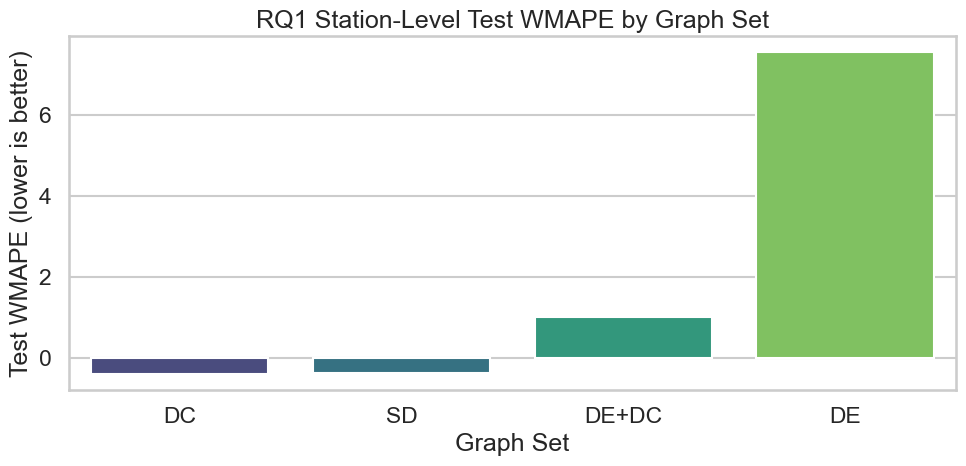

In [6]:
import numpy as np

plt.figure(figsize=(10, 5))
vis_rq1_summary = rq1_summary.copy()
vis_rq1_summary['test_wmape'] = np.log(vis_rq1_summary['test_wmape'])
ax = sns.barplot(data=vis_rq1_summary, x='graph_set', y='test_wmape', palette='viridis')
ax.set_title('RQ1 Station-Level Test WMAPE by Graph Set')
ax.set_xlabel('Graph Set')
ax.set_ylabel('Test WMAPE (lower is better)')
plt.tight_layout()
plt.show()

## Threats To Validity (RQ1)

- RQ1 compares graph families but not all possible model classes; conclusions are conditional on graph_propagation baselines.
- Robustness p-values are model-vs-reference summaries from train_eval and are not direct between-graph-set tests.
- External validity remains bounded by Helsinki-Espoo split and demand dynamics.

In [7]:
best_functional = rq1_summary[rq1_summary['graph_set'].isin(['DE', 'DC', 'DE+DC'])]['test_wmape'].min() if not rq1_summary.empty else np.nan
sd_value = rq1_summary.loc[rq1_summary['graph_set'] == 'SD', 'test_wmape'].min() if not rq1_summary.empty else np.nan

if np.isfinite(best_functional) and np.isfinite(sd_value):
    delta = best_functional - sd_value
    status = 'supported' if delta < 0 else 'mixed_or_not_supported'
    rationale = f'Best functional minus SD test_wmape = {delta:.6f}'
else:
    status = 'insufficient_data'
    rationale = 'Missing SD or functional rows in artifact tables.'

pd.DataFrame([{'rq': 'RQ1', 'claim_status': status, 'rationale': rationale}])

,rq,claim_status,rationale
0,RQ1,supported,Best functional minus SD test_wmape = -0.022866
